## 04. Soluções numéricas de equações em uma variável

Muitas situações práticas em ciências e engenharias envolvem resolver modelos matemáticos dados por uma equação em uma única variável. Em aplicações reais, dificilmente é conveniente ou mesmo possível obter soluções analítica para esses modelos, sendo necessário o uso de métodos numéricos. Um exemplo simples é apresentado a seguir. 

A área do segmento $A_S$ de um círculo de raio $r$ é dada por:
$$A_S=\frac{1}{2}r^2(\theta-sen\theta)$$

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/main/04_solucoes_equacoes_uma_variavel/figuras/png/circulo_de_raio_r.png" width="100">

Para se determinar o ângulo $\theta$ se $A_S$ e $r$ são conhecidos, a equação deve ser resolvida para $\theta$. Obviamente, não é possível escrever $\theta$ explicitamente em termos de $A_S$ e $r$, portanto, a equação não pode ser resolvida analiticamente


Em eletricidade, por exemplo, para calcular a corrente $i$ em um circuito composto de uma fonte de energia ($V$) e uma resistência ($R$), usa-se a Lei de Kirchoff $V - Ri = 0$ e a corrente será dada por $i=V/R$. Mas se o circuito incluir um diodo semicondutor, a equação fica 

$$ V-Ri-\frac{kT}{q}ln\left( \frac{i}{I_s}+1 \right) = 0$$

onde $k$ e $I_s$ são constantes, $q$ é a carga do elétron e $T$ a temperatura do dispositivo. Nesse caso a corrente não pode ser obtida tão facilmente por métodos analíticos, ou seja, "isolando o $i$". Nesse caso podemos fazer uso de métodos computacionais.

Um outro exemplo, em termodinâmica, é a relação entre o calor $Q$ fornecido a um gás e sua variação de temperatura $T_f - T_i$, que sob determinadas condições,  é dada por 

$$ Q = nR \left[ A (T_f-T_i)+ \frac{B}{2}(T_f^2-T_i^2) + \frac{C}{3}(T_f^3-T_i^3) \right].$$

Em que $R$, $A$, $B$ e $C$ são constantes conhecidas. Assim, para calcular a temperatura final $T_f$ quando determinada energia é absorvido pelo gás, sendo o volume e a temperatura conhecidos, é necessário ouso de métodos numéricos.

Podemos citar muitos outros exemplos similares, mas vamos deixar para os exemplos aplicados e exercícios no final do capítulo. O ponto aqui é que todos esses problemas podem ser resolvidos numericamente por métodos de zeros de funções, como será visto a seguir.

A raiz, ou zero de uma função $f(x)$  é o número $\overline{x}$ tal que $f(\overline{x})=0$. Como sabemos, nem sempre é possível resolver uma equação de forma exata, ou analítica, nesses casos fazemos uso de métodos numéricos. 

Uma equação em uma variável real, sempre pode ser escrita na forma 

$$f(x)=0$$

na qual $x$ é a variável independente e  $y = f(x)$ é a variável dependente. Assim, a resolução da equação em uma variável pode ser abordada como um problema de zero de funções.

Graficamente, um zero (ou raiz) é o ponto onde a função $f(x)$ cruza ou toca o eixo $x$. Uma equação $f(x)=0$ pode não ter raiz real, ter uma única raiz ou várias.
![raizes.jpg](https://github.com/tiagoburiol/NUMETHODS/raw/master/3_ZEROS_DE_FUNCOES/images/raizes.jpg)
Figura 4.1 - Exemplo de gráficos de funções com uma única raiz, várias e nenhuma.

#### 4.1 Métodos numéricos

Métodos numéricos, em geral, fornecem uma sequência de aproximações, por meio de um processo iterativo a partir de uma aproximação inicial $x_0$. O processo é interrompido quando a solução aproximadas atinge uma precisão pré-estabelecida. 

Se os valores $x_i$, $i=0,1,2,...$ obtidos pelo processo iterativo estão se aproximando da solução exata $\overline{x}$, ou seja, $|\overline{x} -x_i| \rightarrow 0$ quando $i\rightarrow \infty$, dizemos que a sequência está convergindo. Usualmente o processo iterativo é interrompido quando o valor $\frac{|x_i - x_{i-1}|}{|x_i|} < \epsilon$ onde $\epsilon$ é a tolerância, que dá uma medida da precisão desejada.

Em geral a aplicação de um método numérico para encontrar a raiz de uma equação requer duas etapas:

1. Isolar a raiz, ou seja, encontrar um intervalo $[a,b]$ contendo uma única raíz da equação e;

2. Refinar o intervalo que contém a raíz até atingir a precisão desejada.



Para isolar os zeros de uma função, podemos utilizar algum método gráfico ou testar valores numericamente. Para o método gráfico podemos rescrever a equação $f(x)=0$ numa forma equivamente $f_1(x)=f_2(x)$ e traçar os gráficos de $f_1$ e $f_2$ para verificar onde eles se interceptam. Para testar valores numericamente, basta atribuir valores arbitrários para a variável $x$ e encontrar um par $a$ e $b$ tal que $f(a)\cdot f(b)<0$, mas isso não garante que a raiz seja única em nesse intervalo. 

**Exemplo 4.1:** A equação $f(x)=e^x-sen(x)-2=0$ pode ser escrita como $e^x=senx+2$ então, esboçando os gráficos de $f_1(x)=e^x$ e $f_2(x)=senx+2$, observamos que existe uma única raiz entre $0.5$ e $1.5$.

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/main/04_solucoes_equacoes_uma_variavel/figuras/png/exemplo1.png" width="400">
Figura 4.2 - Localização a raiz pela intersecção dos gráficos

Testando alguns valores numericamente podemos verificar que a raiz está entre $1,0$ e $1,1$, pois $f(1,0) f(1,1) <0$ como mostra a sequência abaixo

In [71]:
import numpy as np
x = np.linspace(0.5, 1.5, 11)
y = np.exp(x)-np.sin(x)-2
for i in range(11):
    print(f'f({x[i]:.1f})={y[i]:.4f}')

f(0.5)=-0.8307
f(0.6)=-0.7425
f(0.7)=-0.6305
f(0.8)=-0.4918
f(0.9)=-0.3237
f(1.0)=-0.1232
f(1.1)=0.1130
f(1.2)=0.3881
f(1.3)=0.7057
f(1.4)=1.0698
f(1.5)=1.4842


Então poderíamos assumir que o ponto médio do intervalo, ou seja $x=1.05$ é uma solução aproximada para essa equação. De fato $f(1.05)\approx-0.00977$ que é relativamente próximo de $0$. Tem-se pelo menos duas casas de precisão.

Como já sabemos, existem bibliotecas em Python que dispõem de muitas funções para matemática computacional, seja por meio de computação simbólica ou numérica. A biblioteca `sympy`, por exemplo, oferece a função `solveset` que pode ser usada para encontrar uma solução analítica para as raízes de $f(x)=x^2-x+1$. Um pequeno exemplo é mostrado abaixo:

In [72]:
from sympy.solvers import solveset
from sympy import Symbol, Eq
x = Symbol('x')
solveset(x**2-x+1, x)

FiniteSet(1/2 - sqrt(3)*I/2, 1/2 + sqrt(3)*I/2)

Uma alternativa numérica é usar a função `fsolve` da biblioteca `scipy`. Por exemplo, para obter a raíz de $f(x)=cos(x)-x$ próximo a $x=2$, podemos fazer:   

In [73]:
from scipy import optimize
f = lambda x: np.cos(x)- x
r = optimize.fsolve(f, 2)
print(r)

[0.73908513]


A seguir vamos apresentar quatro métodos numéricos bem conhecidos para zeros de funções e apresentar alguns exemplos computacionais.

#### 4.2 Método da Bisseção

O _Método da Bisseção_ é o método numérico para resolução de equações do tipo $f(x)=0$, no qual, a partir de um intervalo inicial $[a,b]$ contendo uma única raiz, é gerada uma sequência convergente de aproximações para a raiz. Cada aproximação é obtida dividindo-se intervalo que contém a raiz em dois subintervalos de mesma amplitude. A cada passo, é verificado em qual dos dois subintervalos obtidos contém a raiz e esse é tomado como o intervalo para a próxima iteração. Para verificar o intervalo que contém a raiz, é utilizando o teorema de Bolzano (ou Teorema do Valor Intermediário). 

**Teorema de Bolzano:** Se $f(x)$ é contínua em $[a,b]$ e $f(a)\cdot f(b)<0$, então, existe $\overline{x}$, tal que $a<\overline{x}<b$ e $f(\overline{x})=0$.



A figura 4.2 abaixo ilustra uma situação em que existe uma única raiz no intervalo $[a,b]$.

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/main/04_solucoes_equacoes_uma_variavel/figuras/png/bolzano.png" width="480">

Figura 4.1 - O ponto $x = \overline{x}$ é tal que $\overline{x} \in [a,b]$ e $f(\overline{x})=0$

A sequência de subintervalos será calculada até que a amplitude do intervalo obtido seja menor que uma tolerância pré-estabelecida. Assim, podemos descrever o processo no seguinte algoritmo:

1. Determinar um intervalo inicial $[a,b]$ contendo uma única raíz de $f$;

2. Calcular o ponto médio $x_m=\frac{b+a}{2}$. 

3. Se $|b-a|>\epsilon$ ou $\frac{|x_i - x_{i-1}|}{|x_i|}>\epsilon$ segue, senão, assumir $\overline{x}\approx x_m$ e parar;

4. Se $f(x_m)=0$, então, a raiz $\overline{x}$ é o próprio $x_m$;

5. Se $f(a)\cdot f(x_m)<0$ fazemos $b=x_m$, senão fazemos $a=x_m$  e voltamos ao passo 2;

A seguir serão apresentados alguns exemplos de resolução computacional de equações usando do método da bisseção com Python. Para os codigos apresentados nesses exemplos, será precisoimportar as já conhecidas
bibliotecas `numpy` e `matplotlib` utilizando as linhas mostradas abaixo.   

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

**Exemplo 4.2:** Neste exemplo vamos usar o método da bisseção para  encontrar a raiz da equação $x^2+ln(x)-2=0$  com precisão de $\epsilon = 10^{-3}$. 

*Solução:* Reescrevendo a equação como $x^2-2=-ln(x)$ e plotando os gráficos de $f_1(x)=x^2-2$ e $f_2(x)=-ln(x)$ observamos que existe uma raiz no intervalo $[1.25,1.50]$. A raiz é a abcissa do ponto de intersecção das duas curbas.

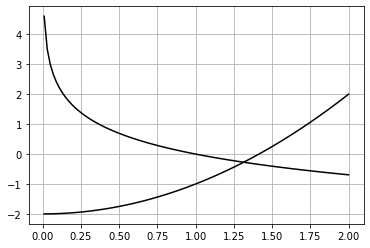

In [74]:
f1 = lambda x: x**2-2
f2 = lambda x: -np.log(x)

x = np.linspace(0.01, 2, 100)
plt.plot(x, f1(x), x, f2(x), color="black")
plt.grid()

Então, na primeira iteração fazemos 

$$x_0 = \frac{a+b}{2}=\frac{1.25-1.5}{2}=1.375$$

Como $f(a)=f(1.25)=-0.2144$, $f(b)=f(1.5)=0.2091$ e $f(x_0)=f(1.375)=0.2091$ temos que a raiz está no intervalo $[a,x_0]$. Então seguimos o processo iterativo obtendo a próxima iteração

$$x_1 = \frac{a+x_0}{2}=\frac{1.25-1.375}{2}=1.3125$$

e obtemos que a raiz está no intervalo $[1.3125, 1.3750]$, pois 
$f(1.3125)=-0.0054$ portanto $f(1.3125)f(1.3750)<0$. Além disso, $\frac{|x_1-x_0|}{|x_0|}=0.0398$ é maior que $\epsilon = 0.001$. Então seguimos o processo iterativo. 

O código abaixo mostra a implementação de uma função para o método da bisseção e também os resultados obtidos ao usá-la para resolver a equação deste exemplo. A tolerância foi atingida na oitava iteração em que obtemos $x_8=1.3135$.


In [75]:
def bissec(f, a, b, eps=0.001):
    err = b-a
    x_ant = a
    while err > eps:
        x = (a+b)/2.0
        if f(x) == 0:
            break
        elif f(x)*f(a) < 0:
            b = x
        else:
            a = x
        err = abs(x - x_ant)/abs(x)
        x_ant = x
        print ("x = %.4f"%x,"E = %.4f"%err, 
               np.round((f(a),f(x),f(b)),3))
    return (x)

In [76]:
bissec(lambda x: x**2 + np.log(x)-2, 1.25, 1.5, 0.001)

x = 1.3750 E = 0.0909 [-0.214  0.209  0.209]
x = 1.3125 E = 0.0476 [-0.005 -0.005  0.209]
x = 1.3438 E = 0.0233 [-0.005  0.101  0.101]
x = 1.3281 E = 0.0118 [-0.005  0.048  0.048]
x = 1.3203 E = 0.0059 [-0.005  0.021  0.021]
x = 1.3164 E = 0.0030 [-0.005  0.008  0.008]
x = 1.3145 E = 0.0015 [-0.005  0.001  0.001]
x = 1.3135 E = 0.0007 [-0.002 -0.002  0.001]


1.3134765625

O exemplo 4.2 mostrou o uso do método da bisseção por meio função `bissec` implementada em Python. A função recebe como entrada a expressão matemática da equação a ser resolvida, como uma função `lambda`, os extremos do intervalo inicial e a precisão desejada para a solução. A cada interação é impresso o valor de $x$, o erro e os valores de $f(a)$, $f(x)$ e $f(b)$ para visualização. O código apresentado aqui é um modelo e serve como exemplo de implementação para ilustrar a aplicação do método. A partir desse modelo, o leitor poderá reproduzir, modificar o código e aplicar conforme sua necessidade ou desejo. 

**Exemplo 4.3:** Neste exemplo vamos localizar as raízes e usar a função `bissect` do exemplo 4.2 para para refinar as aproximações e encontrar as raízes reais de $f(x)=x^3-9x+3$ com precisão $\epsilon = 10^{-2}$.

_Solução:_ Vamos começar fazendo o gráfico da função.

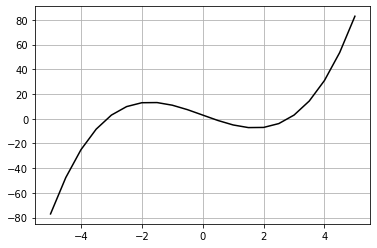

In [77]:
X = np.linspace(-5, 5, 21)
f = lambda x: x**3-9*x+3
plt.plot(X, f(X), color="black")
plt.grid()
plt.show()

Pelo gráfico, podemos ver que parece existirem três raízes distintas $x_1 \in (-4,-3)$, $x_2 \in (0, 1)$ e $x_3 \in (2,3)$. Vamos confirmar criando uma tabela de valores com o código a seguir.

In [78]:
X =  np.linspace(-4,3, 15)
for x in X:
    print ('x=',x, ', f(x)=',f(x))

x= -4.0 , f(x)= -25.0
x= -3.5 , f(x)= -8.375
x= -3.0 , f(x)= 3.0
x= -2.5 , f(x)= 9.875
x= -2.0 , f(x)= 13.0
x= -1.5 , f(x)= 13.125
x= -1.0 , f(x)= 11.0
x= -0.5 , f(x)= 7.375
x= 0.0 , f(x)= 3.0
x= 0.5 , f(x)= -1.375
x= 1.0 , f(x)= -5.0
x= 1.5 , f(x)= -7.125
x= 2.0 , f(x)= -7.0
x= 2.5 , f(x)= -3.875
x= 3.0 , f(x)= 3.0


Pela tabela, confirmamos a existência das raízes nos segintes intervalos: $x_1 \in (-3.5,-3)$, $x_2 \in (0, 0.5)$ e $x_3 \in (2.5,3)$. usaremos agora o método da bisseção para encontrar cada uma das raízes com erro inferior a $10^{-2}$. Faremos isso chamando a função apresentada no exemplo 4.2. As chamadas da função e as saídas obtidas são mostradas a seguir.

In [79]:
print ("x1=", bissec(f, -3.5, -3, 0.01))
print ("x2=", bissec(f, 0, 0.5, 0.01))
print ("x3=", bissec(f, 2.5, 3, 0.01))

x = -3.2500 E = 0.0769 [-2.078 -2.078  3.   ]
x = -3.1250 E = 0.0400 [-2.078  0.607  0.607]
x = -3.1875 E = 0.0196 [-0.698 -0.698  0.607]
x = -3.1562 E = 0.0099 [-0.036 -0.036  0.607]
x1= -3.15625
x = 0.2500 E = 1.0000 [ 0.766  0.766 -1.375]
x = 0.3750 E = 0.3333 [ 0.766 -0.322 -0.322]
x = 0.3125 E = 0.2000 [ 0.218  0.218 -0.322]
x = 0.3438 E = 0.0909 [ 0.218 -0.053 -0.053]
x = 0.3281 E = 0.0476 [ 0.082  0.082 -0.053]
x = 0.3359 E = 0.0233 [ 0.014  0.014 -0.053]
x = 0.3398 E = 0.0115 [ 0.014 -0.019 -0.019]
x = 0.3379 E = 0.0058 [ 0.014 -0.002 -0.002]
x2= 0.337890625
x = 2.7500 E = 0.0909 [-0.953 -0.953  3.   ]
x = 2.8750 E = 0.0435 [-0.953  0.889  0.889]
x = 2.8125 E = 0.0222 [-0.065 -0.065  0.889]
x = 2.8438 E = 0.0110 [-0.065  0.403  0.403]
x = 2.8281 E = 0.0055 [-0.065  0.167  0.167]
x3= 2.828125


**Exemplo 4.3:** Calcular, pelo método da bisseção, corretamente até a terceira casa decimal, a raiz da equação  $\left( \frac{x}{2} \right)^2-sen(x) = 0$, localizada no intervalo ($a_0=1$ e $b_0=3$).

In [81]:
f = lambda x: (x/2)**2 - np.sin(x)
x = bissec(f,1, 3, 0.001)
print(f'x = {x}')

x = 2.0000 E = 0.5000 [-0.591  0.091  0.091]
x = 1.5000 E = 0.3333 [-0.435 -0.435  0.091]
x = 1.7500 E = 0.1429 [-0.218 -0.218  0.091]
x = 1.8750 E = 0.0667 [-0.075 -0.075  0.091]
x = 1.9375 E = 0.0323 [-0.075  0.005  0.005]
x = 1.9062 E = 0.0164 [-0.036 -0.036  0.005]
x = 1.9219 E = 0.0081 [-0.016 -0.016  0.005]
x = 1.9297 E = 0.0040 [-0.005 -0.005  0.005]
x = 1.9336 E = 0.0020 [-0.    -0.     0.005]
x = 1.9355 E = 0.0010 [-0.     0.002  0.002]
x = 1.9346 E = 0.0005 [-0.     0.001  0.001]
x = 1.9345703125


**Exemplo 4.4:** Use o método da bisseção para obter um zero da função $f(x)=x\log x-1$ com precisão $\epsilon = 0.01$

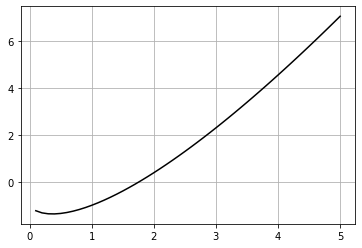

In [82]:
X = np.linspace(0.1, 5)
f = lambda x: x*np.log(x)-1
plt.plot(X, f(X), color="black")
plt.grid()
plt.show()

In [83]:
bissec(f,1.5, 2.0, 0.001)

x = 1.7500 E = 0.1429 [-0.021 -0.021  0.386]
x = 1.8750 E = 0.0667 [-0.021  0.179  0.179]
x = 1.8125 E = 0.0345 [-0.021  0.078  0.078]
x = 1.7812 E = 0.0175 [-0.021  0.028  0.028]
x = 1.7656 E = 0.0088 [-0.021  0.004  0.004]
x = 1.7578 E = 0.0044 [-0.008 -0.008  0.004]
x = 1.7617 E = 0.0022 [-0.002 -0.002  0.004]
x = 1.7637 E = 0.0011 [-0.002  0.001  0.001]
x = 1.7627 E = 0.0006 [-0.001 -0.001  0.001]


1.7626953125

### 4.4 Método do ponto fixo

O método do ponto fixo (ou das aproximações sucessivas), consiste em reescrever a equação $f(x)=0 $ em uma equação equivalente $x = \phi (x)$ em que $\phi (x)$ é a de iteração. Então, a raiz $\overline{x}$ é obtida por meio de uma sequência de de soluções aproximadas, geradas pelo processo iterativo dado por

$$ x_{i+1} = \phi(x_i) , \,\,\,\,\, i = 0,1,2,...$$

Existem muitas formas diferentes de se obter a função de iteração, como é exemplificado a seguir.

**Exemplo 4.6:** Seja a equação $f(x) = x^2-5x=0$, então, algumas possíveis funções de iteração são

(a) $x_{i+1} = \phi(x_i) = \sqrt{5x_i}$

(b) $x_{i+1} = \phi(x_i) = \frac{x_i^2}{5}$

(c) $x_{i+1} = \phi(x_i) = x^2 - 4$

**Exemplo 4.7:** Seja a equação $f(x) = x^3-x-7=0$, então, algumas possíveis funções de iteração são:

(a) $x_{i+1} = \phi(x_i) = x_{i}^3-7$

(b) $x_{i+1} = \phi(x_i) = \sqrt[3]{x+7}$

(c) $x_{i+1} = \phi(x_i) = 7/(x^2-1)$

De modo geral, sempre é possível obter uma função de iteração multiplicando uma função qualquer $\theta(x)$ pela equação $f(x)=0$ e somando $x$ a ambos os lados obtendo-se 

$$x_{i+1} = \phi(x_i) = f(x)\theta(x_i)+x$$

O processo iterativo gera uma sequência de soluções aproximadas a partir de uma aproximação inicial $x_0$, como é mostrado abaixo

$$x_{1} = \phi(x_0)$$

$$x_{2} = \phi(x_1)$$

$$x_{3} = \phi(x_2)$$

$$\vdots$$

$$x_{i+1} = \phi(x_{i})\simeq \overline{x}$$

Geometricamente, interpretamos o processo iterativo como é mostrado nas figuras abaixo, para dois casos distintos. O ponto de intersecção entre o gráfico de $\phi(x)$ e a reta $y=x$ é o ponto cuja abcissa é a raiz procurada $\overline{x}$.

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/main/04_solucoes_equacoes_uma_variavel/figuras/png/exemplo7ab.png" width="600">
Figura 4.2 - Método do ponto fixo convergindo para a raiz


Nem sempre o método será convergente, a convergêcia dependerá da  inclinação do gráfico da função na vizinhança da raiz, como é enunciado a seguir.  

**Condição de convergência do método do ponto fixo:** Seja $\phi(x)$ uma função contínua e derivável em $I=[a,b]$ centrado em $\overline{x}$, então, se $|\phi'(x)|<1$ em $I$, a sequência ${x_k}$, $k=0,1,2,3,..$ que é dada por $x_{k+1}=\phi(x_k)$ converge para a raiz $\overline{x}$ procurada.

No caso do processo iterativo gerar sequências divergentes, uma interpretação geométrica é mostrada na figura a seguir. 

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/main/04_solucoes_equacoes_uma_variavel/figuras/png/exemplo7cd.png" width="600">
Figura 4.3 - Método do ponto fixo divergindo

**Observação:**
Para os exemplos computacionais a seguir precisaremos carregar as já conhecidas bibliotecas `numpy` e `matplotlib` utilizando as linhas mostradas abaixo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

**Exemplo 4.8:** Vamos usar o método do ponto fixo para encontrar uma raiz para $f(x)=x-cos(x/2)$ com $\epsilon = 10^{-3}$.

Aqui a forma mais obvia de reescrevermos a equação de modo a termos $x = \phi (x)$ é fazer $x=cos(x/2)$ o que nos fornece o processo iterativo $x_{i+1}=cos(x/2)_i$. Vamos então buscar uma boa aproximação inicial $x_0$ e avaliar a convergência. Começamos olhando os gráficos e $f_1(x)=x$ e $f_ 2(x)=cos(x/2)$.

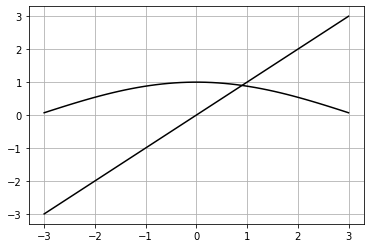

In [28]:
import numpy as np
import matplotlib.pyplot as plt
f1 = lambda x: np.cos(x/2)
f2 = lambda x: x
X = np.linspace(-3, 3)
plt.plot(X, f1(X),X, f2(X),
        color = "black") 
plt.grid()
plt.show()

Observamos que existe uma única raiz entre $0$ e $1$, tomamos então o ponto médio $x_0=0,5$ como aproximação inicial. Avaliando a função $|\phi'(x)|= |-\frac{sen(x/2)}{2}|$ em torno de $x_0=0,5$ também verificamos que $|-\frac{sen(x/2)}{2}|<1$, logo, o processo iterativo é convergente. Então, fazendo algumas iterações até que a diferença relativa $\frac{|x_i - x_{i-1}|}{|x_i|}$ atinja um valor menor que 0.001 obtemos:

$x_0=0.5$

$x_1=cos(x_0/2) = cos(0.25)= 0.968912$

$x_2=cos(x_1/2) = cos(0.968912/2)= 0.884928$

$x_3=cos(x_2/2) = cos(0.0.903699/2)= 0.0.903699$

$\vdots$


O erro após a 3ª iteração é $\frac{|x_2 - x_1|}{|x_1|} = 0.020771>10^{-3}$, então, a precisão desejada ainda não foi atingida.  Devemos prosseguir o processo iterativo. Na quinta iteração a precisão é atingida, como podemos ver ao resolver computacionalmente com o código mostrado abaixo.

In [29]:
x = 0.5
err = 1.0
x_ant = x

while err>0.001:
    x = f1(x)
    err = abs(x-x_ant)/abs(x)
    x_ant = x
    print (f' x = {x}, erro = {err}')

 x = 0.9689124217106447, erro = 0.48395748800780714
 x = 0.8849283373389375, erro = 0.09490495538232536
 x = 0.903699330715045, erro = 0.020771281706333838
 x = 0.8996410217990137, erro = 0.004511031419972279
 x = 0.9005251594201672, erro = 0.0009818022427299535


Como é possivel notar, a sequência convergiu para o ponto fixo $x \approx 0.9$.

**Exemplo 4.9:** Agora vamos calcular todas as raízes de 𝑓(𝑥)=𝑙𝑛𝑥−𝑥+2=0 pelo método ponto-fixo até que o erro relativo seja inferior a 0.0001. 

Precisamos encontrar uma função de interação $\phi (x)$ escrevendo uma equação equivalente a $f(x)=lnx−x+2=0$ na forma $x=\phi (x)$. Sabemos que existem diferentes formas de fazer isso e que as funções obtidas podem gerar sequências convergentes ou não. Se $|\phi '(x)|<1$ em torno da raiz, a sequência será convergente. Entre as equações possíveis, tem-se $\phi_1(x)=ln(x)+2$ e $\phi_2(x)=e^{x−2}$. Mas antes de fazer as iterações vamos localizar as raízes.

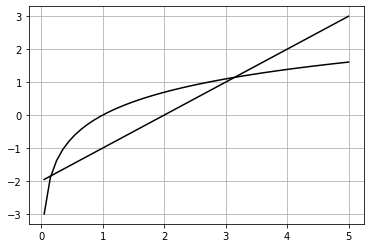

In [30]:
xi = np.linspace(0.05, 5)
plt.plot(xi, np.log(xi), xi, xi-2, color="black") 
plt.grid()
plt.show()

Fazendo os gráficos de $f_1(x)=ln(x)$ e de $f_2(x)=x-2$ vemos que há uma raiz próxima de $x=0$ e outra próximo de $x=3$. Analisando a convergência da função de iteração $\phi_1(x)=ln(x)+2$ fazendo $|\phi_1'(x)|=|1/x|$ notamos que a função converge para a raiz próxima de $x=3$ pois tem-se que $|\phi_1'(x)|=|1/x|<1$ na vizinhanca de $3$, mas o mesmo não ocorre para valores de $x$ próximos de $0$. Por outro lado, observamos que  $|\phi_2'(x)|=|e^{x−2}|<1$ na vizinhança de $x=0$ portano pode a função de iteração $\phi_2(x)$ ser usada para encontrar a menor raiz da equação.

Vamos, dessa vez, construir uma função para o método do ponto fixo

In [84]:
def pontofixo(phi,x,eps):
    err = 10.0
    x_ant = x
    
    while err>eps:
        x = phi(x)
        err = abs(x-x_ant)/abs(x)
        x_ant = x
        print ("| x=%.9f"%x, "| err=%.9f"%err)
    return (x)

A função `pontofixo` recebe a função de iteração, a aproximação iniciao e a precisão desejada e processa as iterações imprimindo os resultados até que a tolerância seja atingida. A seguir é executada para $f_1(x)=ln(x)+2$, $x_0=3$ e $\epsilon=0.0001$:

In [85]:
pontofixo(lambda x: np.log(x)+2, 3.0, 0.0001)

| x=3.098612289 | err=0.031824662
| x=3.130954362 | err=0.010329781
| x=3.141337866 | err=0.003305440
| x=3.144648781 | err=0.001052873
| x=3.145702209 | err=0.000334878
| x=3.146037143 | err=0.000106462
| x=3.146143611 | err=0.000033841


3.1461436109912895

Em 7 iterações a solução procurada foi obtida. Agora, testando para $f_2(x)=e^{x-2}$, $x_0=0.5$ e $\epsilon=0.0001$:

In [38]:
pontofixo(lambda x: np.exp(x-2), 0.5, 0.0001)

| x=0.223130160 | err=1.240844535
| x=0.169166839 | err=0.318994679
| x=0.160279973 | err=0.055445889
| x=0.158861897 | err=0.008926471
| x=0.158636778 | err=0.001419082
| x=0.158601070 | err=0.000225144
| x=0.158595407 | err=0.000035709


0.15859540701599245

Novamente foram necessárias 7 iterações.

**Exemplo 4.10:**
Vamos encontrar a menor raíz positiva de $ f(x)=2x-\tan(x)$ com $\epsilon < 0.01$.

Inicialmente precisamos localizar a menor raiz positiva da função. Sabemos que há uma raíz em $x=0$ e a outra é próxima de $\pi/2$. Para conseguir uma boa aproximação inicial, podemos calcular o valor da função para alguns valores de $x$ e fazer o gráfico:

In [46]:
for x in np.linspace(0,np.pi,10):
    print (f'f({np.round(x,3)})= {2*x-np.tan(x)}')

f(0.0)= 0.0
f(0.349)= 0.33416146653152945
f(0.698)= 0.5571637704181837
f(1.047)= 0.3623442948243185
f(1.396)= -2.8787550164267794
f(1.745)= 9.16194032360637
f(2.094)= 5.920841012355269
f(2.443)= 5.726021536761403
f(2.793)= 5.9490238406480564
f(3.142)= 6.283185307179586


Nos resultados acima, para valores da função entre 0 e $\pi$, já vemos que a menor raíz positiva está entre 1.047 e 1.396. Embora possa parecer que existe outra raiz entre 1.396 e 1.745, essa é uma conclusão errada, pois a função não é contínua em $x = \pi/2$. Fazendo o gráfico de $f_1(x)=2x$ e $f_2(x)=tan(x)$ podemos ter uma ideia melhor da localização dessa raiz e concluir que ela está próxima de $x=1.2$.

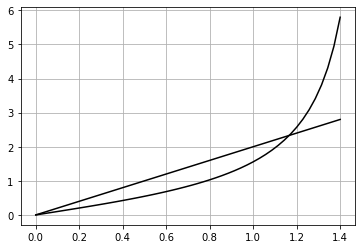

In [87]:
X = np.linspace(0,1.4,50)
plt.plot(X, np.tan(X),X, 2*X,color='k') 
plt.grid()
plt.show()


Para o método do ponto fixo, a primeira função de iteração que imaginamos é $\phi(x)=\tan(x)/2$. Mas nesse caso o método converge apenas para a raiz nula já que $|\phi'(x)|=|\tan(x)/2|$ é maior que 1 para valores próximos de $x=1.2$ como podemos ver abaixo.

In [88]:
for x in np.linspace(0.8,1.2,6):
    print ('x =',x, "phi' =",  (1/(np.cos(x))**2 ))

x = 0.8 phi' = 2.060155558164756
x = 0.88 phi' = 2.4632872860442183
x = 0.96 phi' = 3.040205121877592
x = 1.04 phi' = 3.902302747102836
x = 1.12 phi' = 5.268171142025814
x = 1.2 phi' = 7.615963967207052


Assim precisamos de uma outra função de iteração, talvez $\phi(x) = \tan^{-1}(2x)$. Podemos testar fazendo algumas iterações e verificando que está se aproximando de um valor fixo próximo de $x=1.165$.

In [53]:
pontofixo(lambda x: np.arctan(2*x), 1.2, 0.001)

| x=1.176005207 | err=0.020403645
| x=1.168783233 | err=0.006179053
| x=1.166560401 | err=0.001905459
| x=1.165871559 | err=0.000590839


1.165871558884363

Além disso, podemos verificar que a convergência é garantida para essa função de iteração já que satisfaz o critério de convergência uma vez que  $\frac{d}{dx}(tan^{-1})=\frac{1}{1+x^2}$.

#### 4.4 Método de Newton ou método das tangentes

O _Método de Newton_  (_Newton-Raphson_ ou _método das tangentes_) para zeros de funções reais em variável pode ser deduzido a partir do método do ponto fixo ao buscar uma função de interação $\phi(x)$ tal que $|\phi'(x)|<1$. Dessa forma, escolhendo-se uma "boa" aproximação inicial $x_0$ garantimos que a sequência de soluções aproximadas irá convergir para a solução exata $\overline{x}$.

Para isso, estabelecemos que $|\phi'(\overline{x})|=0$, assim, espera-se que em torno de $\overline{x}$ tenhamos $|\phi'(x)|<1$, então escrevemos uma forma geral para a função $\phi(x)$ multiplicando $f(x)=0$ por uma função desconhecida $\theta(x)$ e somamos $x$ em ambos os lados da equação obtendo

$$x = x+\theta(x)f(x)$$ 
 
 ou
 
$$\phi(x) = x+\theta(x)f(x)$$ 

nas quais $\theta(x)$ é uma função de $x$ tal que $\theta(\overline{x})\neq 0$. Então, para o ponto fixo $x=\overline{x}$ tem-se $\phi(\overline{x}) = \overline{x}$. Assim, derivando a função $\phi(x)$ e avaliando no ponto fixo obtemos:

$$\phi'(x) = 1+\theta'(x)f(x) + \theta(x)f'(x)$$

avaliando em $\overline{x}$

$$\phi'(\overline{x}) = 1+\theta'(\overline{x})f(\overline{x}) + \theta(\overline{x})f'(\overline{x})$$


$$ 0 = 1 + \theta(\overline{x})f'(\overline{x}) $$

então temos 

$$  \theta(\overline{x}) = -\frac{1}{f'(\overline{x})} $$

Assim, escolhento $\theta(x) = -\frac{1}{f'(x)}$ e substituindo em $\Phi(x) = x+\theta(x)f(x)$ obtemos

$$ \phi(x) = x - \frac{f(x)}{f'(x)}$$

que fornece o processo iterativo do método de Newton por meio de:

$$ x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)}$$

Desde que  $f'(x_i) \neq 0$, a cada iteração o ponto $x_{i+1}$ corresponde à intersecção da reta tangente à função $f(x)$ no ponto $(x_i, f(x_i))$, assim, o método de Newton pode ser interpretado geometricamente como mostra a figura 4.4 abaixo.

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/main/04_solucoes_equacoes_uma_variavel/figuras/png/newton.png" width="480">
Figura 4.4 - Interpretação geométrica do método de Newton


O método de Newton também pode ser deduzido a partir do polinômio de Taylor em torno de $x_0$:

$$f(x) = f(x_0)+
        f^{(1)}(x_0)(x-x_0)+ 
        f^{(2)}(x_0)\frac{(x-x_0)^2}{2!}+
        f^{(3)}(x_0)\frac{(x-x_0)^3}{3!}+...$$
        
desprezando os termos de maior grau, os quais assumem valores muito pequenos para $x$ suficientemente próximo de $x_0$, obtemos a seguinte aproximação para $f(x)$:

$$f(x) \approx f(x_0)+f'(x_0)(x-x_0)$$

fazendo $x=\overline{x}$, como $f(\overline{x})=0$, tem-se:

$$0 \approx f(x_0)+f'(x_0)(\overline{x}-x_0)$$

ou

$$\overline{x} \approx x_0 - \frac{f(x_0)}{f'(x_0)}$$

que fornece o processo iterativo 

$$ x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)} \,,\,\,\,\,\, i=1,2,...$$

Vejamos agora alguns exemplos. 

**Exemplo 4.11:** Vamos encontrar a raiz de $f(x)=ln(x)+x-4$ usando o método de Newton.

Para obter uma aproximação inicial podemos usar o recurso gráfico fazendo.

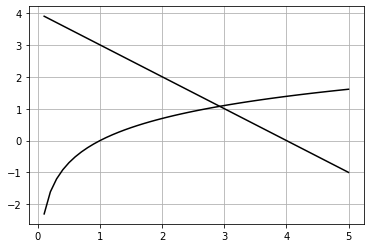

In [55]:
xi = np.linspace(0.1, 5)
plt.plot(xi, np.log(xi), xi, 4-xi, color="black") 
plt.grid()
plt.show()

O gráfico mostra que existe uma raiz entre 2 e 3, então, iniciando com $x_0=2$ obtemos pelo método de Newton:

$x_1 = x_0-\frac{f(x_0)}{f'(x_0)}=2-\frac{ln(2) +2 -4}{1/2+1}=2.871235$

$x_2 = x_1-\frac{f(x_1)}{f'(x_1)}=2-\frac{ln(2.871235) +2.871235-4}{1/2.871235+1}=2.926137$

$x_3 = x_2-\frac{f(x_2)}{f'(x_2)}=2.926137-\frac{ln(2.926137) +2.926137 -4}{1/2.926137+1}=2.926271$

Assim, em três interações chega-se a uma solução com $E=0.000046$. Usando Python podemos chegar a esses resultados com o código mostrado abaixo:

In [69]:
f = lambda x: math.log(x)+x-4.0
df = lambda x: 1./x +1  
x = 2
x_ant = x
err = 10.0

while err>0.0001:
    x = x - f(x)/df(x)
    err = abs(x-x_ant)/abs(x)
    x_ant = x
    print ("| x=%.6f"%x, "| err=%.6f"%err)

| x=2.871235 | err=0.303436
| x=2.926137 | err=0.018762
| x=2.926271 | err=0.000046


Observe que neste exemplo a derivada $f'(x)$ foi escrita explicitamente no código como `df = lambda x: 1./x +1`. Em Python, podemos combinar computação simbólica com numérica de modo a obter uma expressão para a derivada de uma função $f(x)$ de forma automática. 

Por exemplo, escrevendo a função $f(x)=ln(x)+x-4$ como uma expressão do `sympy` podemos obter a derivada como é mostrado abaixo.

In [66]:
import sympy
x = sympy.symbols('x')
expr = sympy.log(x)+x-4.0
sympy.diff(expr)

1 + 1/x

Para converter a expressão uma `sympy` em uma função `lambda` do `numpy` utilizamos `sympy.lambdify` como é mostrado a seguir:  

In [68]:
f = sympy.lambdify((x), expr, 'numpy')
df = sympy.lambdify((x), sympy.diff(expr), 'numpy')

Dessa forma podemos usar o mátodo de Newton sem ter que calcular a derivada de $f(x)$ previamente. 

#### 4.5 Método das secantes

O método das secantes consiste em aproximarmos a derivada $f'(x_i)$ do método de Newton, que ocorre da seguinte forma:

$$ f'(x_i) \approx \frac{f(x_i) - f(x_{i-1})}{x_i-x_{i-1}}$$


Observe que, neste caso, estamos trocando a inclinação da reta tangente pela inclinação da reta secante à curva, conforme a figura abaixo. Assim, dados os pontos $x_{i−1}$ e $x_i$ , onde a reta secante, passando por $(x_{i−1}, f(x_{i−1}) )$ e $(x_i , f(x_i))$, cortar o eixo das abscissas, temos a aproximação $x_{i+1}$ para a raiz $\overline{x}$, conforme ilustrado 

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/main/04_solucoes_equacoes_uma_variavel/figuras/png/secantes.png" width="500">

Assim, o método de Newton, dado por

$$ x_{i+1} = x_i-\frac{f(x_i)}{f'(x_i)}$$

é modificado da seguinte forma

$$ x_{i+1} = x_i-\frac{ f(x_i)}{ \,\, \frac{f(x_i) - f(x_{i-1})}{x_i-x_{i-1}}\,\,}$$

Que pode ser reescrito como 

$$ x_{i+1} = x_i-\frac{ x_{i-1}f(x_i) - x_i f(x_{i-1})}{ f(x_i) - f(x_{i-1})}$$

**Exemplo 4.12:** Vamos agora encontrar a raiz da equação $ln(x)+x-4=0$ com tolerância $\epsilon = 0.0001$ usando o método das secantes.

Com base no que já foi feito no exemplo 4.11 podemos obter as iterações com o código mostrado a seguir.

In [70]:
err = 10.0
x0 = 1.0
x1 = 2.0

f = lambda x: math.log(x)+x-4.0

while err> 0.0001:
    x = (x0*f(x1)-x1*f(x0))/(f(x1)-f(x0))
    err = abs(x-x1)/abs(x) 
    x0 = x1
    x1 = x
    print ("x=%.9f"%x, "E=%.9f"%err)

x=2.771848327 E=0.278459799
x=2.918482896 E=0.050243422
x=2.926217104 E=0.002643074
x=2.926271044 E=0.000018433


#### Exercícios 
1. Calcule, se possível, as raízes das seguintes funções com pelo menos 3 casas de precisão:

a) $f(x) = \sqrt{x}-5^{-x}$  

b) $f(x) = e^{x} + x$

c) $f(x) = xln(x)-1$

d) $f(x) = sen(x)-1/2$

e) $x^3-7x^2+14x-6=0$  

f) $2x cos(2x)-(x+1)^2=0$

g) $x-2^{-x}=0$

h) $2+cos(e^x-2)-e^x=0$

i) $f(x) = –0.5x^2 + 2.5x + 4.5$

j) $f(x) = 5x^2 – 5x^2 + 6x -2$

k) $f(x) = –25 + 82x – 90x^2 + 44x^3 – 8x^4 + 0.7x^5$

l) $f(x) = – 12 – 21x + 18x^2 – 2.75x^3$